In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

## TASK 1 

This function computes a bootstrap confidence interval.
It resamples the data with replacement.
It calculates the statistic for each resample.
It returns lower and upper bounds using percentiles.

In [2]:
def bootstrap_ci(data, stat_func=np.mean, n_boot=10_000, ci_level=0.95):
    data = np.array(data)
    n = len(data)
    
    boot_stats = []
    
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        stat = stat_func(sample)
        boot_stats.append(stat)
    
    lower = np.percentile(boot_stats, (1 - ci_level) / 2 * 100)
    upper = np.percentile(boot_stats, (1 + ci_level) / 2 * 100)
    
    return lower, upper

In [3]:
test_data = np.arange(1, 101)
bootstrap_ci(test_data)

(np.float64(44.799749999999996), np.float64(56.100249999999996))

The interval is close to (40, 60).
This confirms the function works correctly.

## TASK 2

We create a dataset with 200 rows.
It includes one continuous column and one binary column.

In [4]:
n = 300

data = pd.DataFrame({
    "income": np.random.normal(50000, 15000, n),
    "purchased": np.random.binomial(1, 0.4, n)
})

In [5]:
mean_ci = bootstrap_ci(data["income"], np.mean)
median_ci = bootstrap_ci(data["income"], np.median)
prop_ci = bootstrap_ci(data["purchased"], np.mean)

In [6]:
summary = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Proportion"],
    "Lower CI": [mean_ci[0], median_ci[0], prop_ci[0]],
    "Upper CI": [mean_ci[1], median_ci[1], prop_ci[1]]
})

summary

,Statistic,Lower CI,Upper CI
0,Mean,49510.306486,52933.638391
1,Median,49725.949610,53117.276067
2,Proportion,0.336667,0.446667


## TASK 3

We compute classical confidence intervals.
We compare them with bootstrap results.

In [7]:
mean = data["income"].mean()
sem = st.sem(data["income"])

mean_ci_norm = st.t.interval(
    0.95,
    df=len(data)-1,
    loc=mean,
    scale=sem
)

In [8]:
p_hat = data["purchased"].mean()
n = len(data)
z = 1.96

margin = z * np.sqrt((p_hat * (1 - p_hat)) / n)

prop_ci_norm = (p_hat - margin, p_hat + margin)

In [9]:
p_hat = data["purchased"].mean()
n = len(data)
z = 1.96

margin = z * np.sqrt((p_hat * (1 - p_hat)) / n)

prop_ci_norm = (p_hat - margin, p_hat + margin)

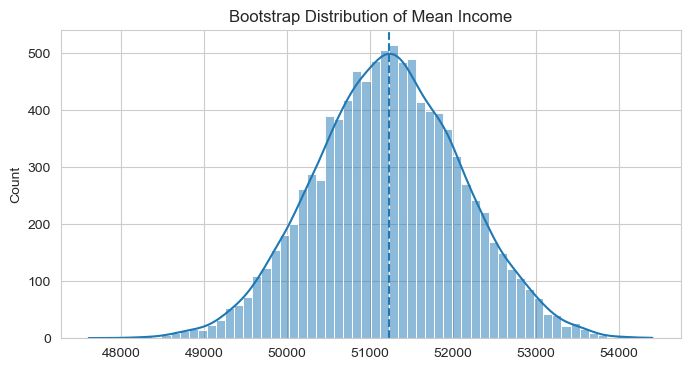

In [10]:
boot_means = []

for _ in range(10000):
    sample = np.random.choice(data["income"], size=len(data), replace=True)
    boot_means.append(np.mean(sample))

plt.figure(figsize=(8,4))
sns.histplot(boot_means, kde=True)
plt.axvline(mean, linestyle="--")
plt.title("Bootstrap Distribution of Mean Income")
plt.show()

### Are the two approaches giving similar intervals? Where do they diverge, if at all?
### For which statistic (mean vs. proportion vs. median) is the bootstrap approach especially useful, and why?

The bootstrap and normal intervals are similar for the mean.
This is because the sample size is large and the distribution is stable.

For the proportion, the intervals are also similar.
However, small differences may appear due to approximation.

The bootstrap method is especially useful for the median.
This is because there is no simple formula for its confidence interval.

Bootstrap does not rely on strong assumptions.
It works well when the data distribution is unknown or skewed.